# Medical Insurance Cost Prediction using Machine Learning (Linear Regression)

This project predicts medical insurance charges based on personal attributes such as age, BMI, smoking status, number of children, sex, and region.

The model used is **Linear Regression**, a machine learning algorithm used for predicting continuous numerical values.

## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

import numpy as np

## Load Dataset

We load the insurance dataset and inspect its structure.

In [2]:
df = pd.read_csv("insurance.csv")

print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


## Dataset Overview

We check:
- Dataset shape
- Columns
- First rows
- Missing values

In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (1338, 7)

Columns:
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

First 5 Rows:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


## Exploratory Data Analysis (EDA)

We visualize important relationships between features and insurance charges.

### Age vs Insurance Charges

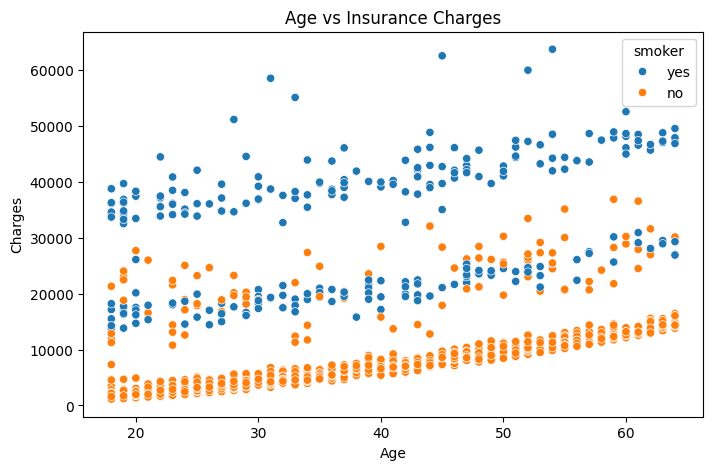

In [4]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="age", y="charges", hue="smoker")

plt.title("Age vs Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Charges")

plt.show()

### BMI vs Insurance Charges

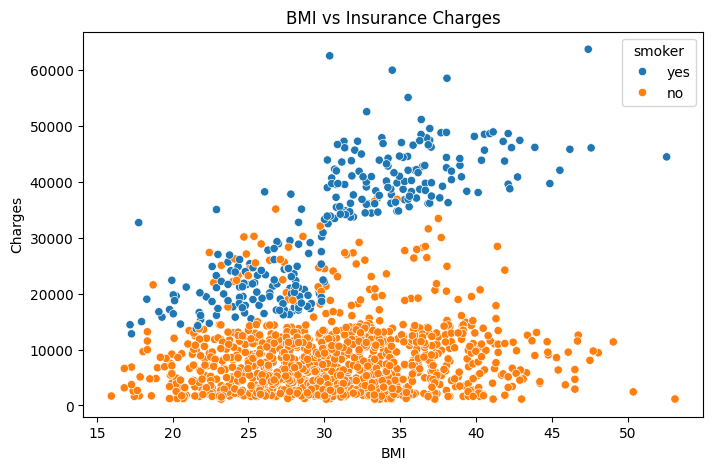

In [5]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker")

plt.title("BMI vs Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")

plt.show()

### Smoking Status vs Charges

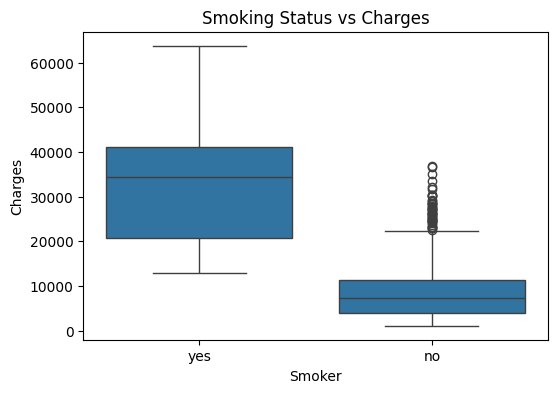

In [6]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="smoker", y="charges")

plt.title("Smoking Status vs Charges")
plt.xlabel("Smoker")
plt.ylabel("Charges")

plt.show()

## Encoding Categorical Data

We convert categorical columns into numerical format using one-hot encoding.

In [7]:
df = pd.get_dummies(df, drop_first=True)

print("Dataset after encoding:")
print(df.head())

Dataset after encoding:
   age     bmi  children      charges  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0  16884.92400     False        True             False   
1   18  33.770         1   1725.55230      True       False             False   
2   28  33.000         3   4449.46200      True       False             False   
3   33  22.705         0  21984.47061      True       False              True   
4   32  28.880         0   3866.85520      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


## Feature Selection

We separate:
- Features (X)
- Target Variable (y)

In [8]:
X = df.drop("charges", axis=1)
y = df["charges"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1338, 8)
Target shape: (1338,)


## Train Test Split

Dataset is divided into:
- 80% Training Data
- 20% Testing Data

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (1070, 8)
Testing data shape: (268, 8)


## Linear Regression Model Training

In [10]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


## Model Prediction

In [11]:
y_pred = model.predict(X_test)

print("Predictions completed!")

Predictions completed!


## Model Evaluation

We evaluate performance using:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)

In [12]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Absolute Error (MAE): 4181.194473753654
Root Mean Squared Error (RMSE): 5796.2846592762735


## Actual vs Predicted Charges Visualization

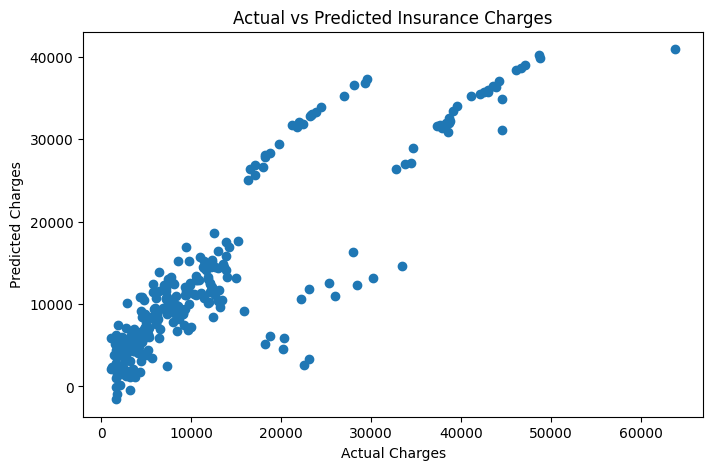

In [13]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)

plt.title("Actual vs Predicted Insurance Charges")
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")

plt.show()

## Conclusion

In this project:

- Insurance dataset was loaded and explored  
- Important relationships were visualized  
- Categorical data was encoded  
- Linear Regression model was trained  
- Insurance charges were predicted  
- Model performance was evaluated using MAE and RMSE  

This project demonstrates a complete regression-based machine learning workflow.